<a href="https://colab.research.google.com/github/irfanrois75-dotcom/Visi-Komputer/blob/main/Pertemuan6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Threshold


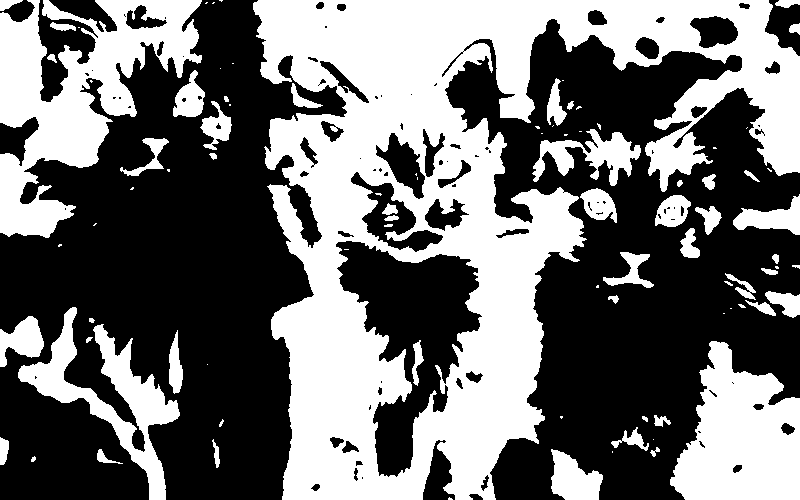

Edges


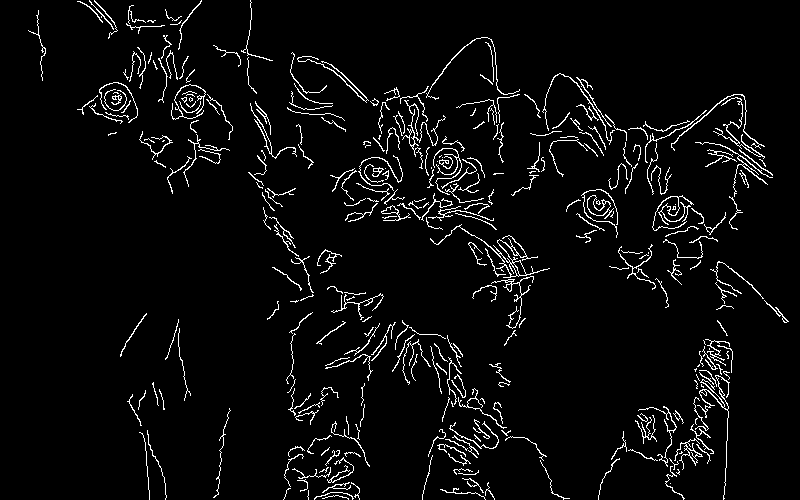

Combined


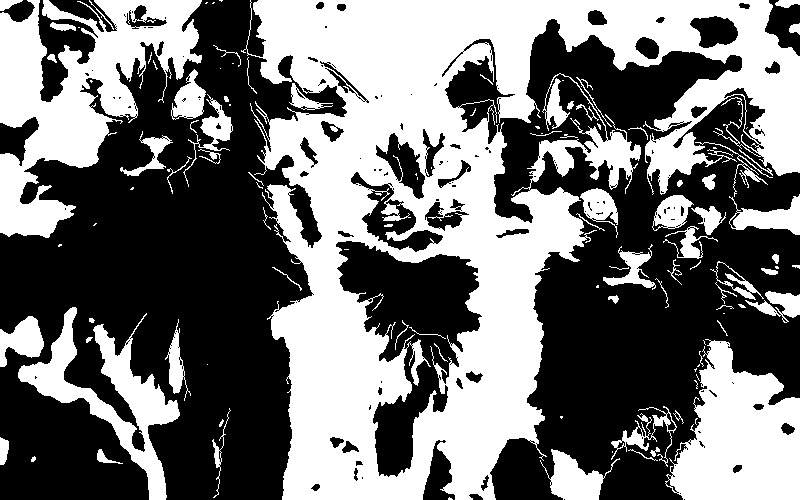

Mask Final


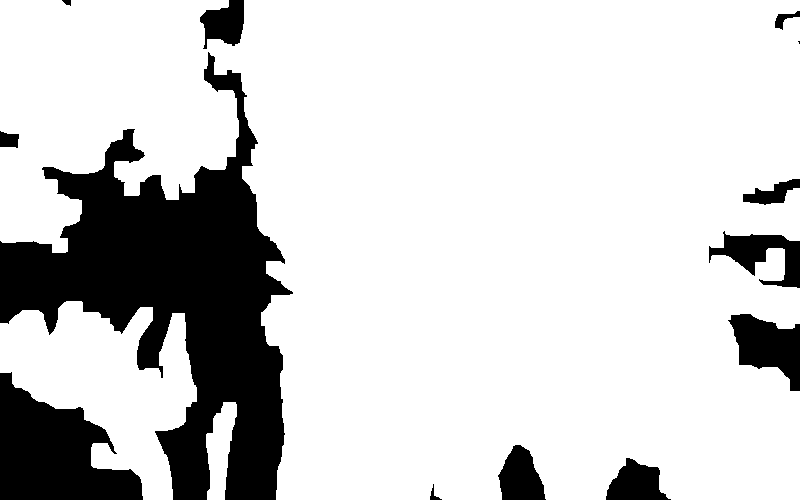

Hasil Segmentasi


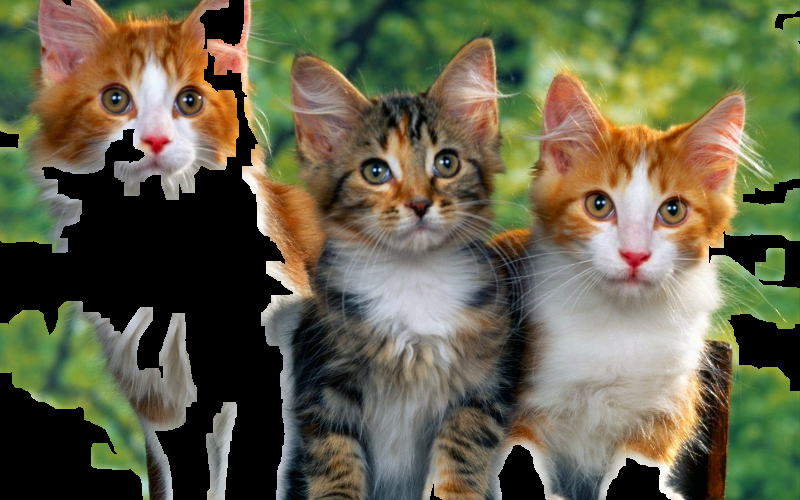

In [25]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =====================
# 1. LOAD GAMBAR
# =====================
image_path = 'Kucing.JPG'
image = cv2.imread(image_path)
image = cv2.resize(image, (800, 500))

# =====================
# 2. PREPROCESSING
# =====================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# =====================
# 3. THRESHOLD (PISAH FOREGROUND)
# =====================
_, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY_INV)

# =====================
# 4. CANNY EDGE
# =====================
edges = cv2.Canny(blur, 50, 150)

# =====================
# 5. GABUNGKAN EDGE + THRESHOLD
# =====================
combined = cv2.bitwise_or(thresh, edges)

# =====================
# 6. MORPHOLOGY (BIAR OBJEK UTUH)
# =====================
kernel = np.ones((7,7), np.uint8)
mask = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
mask = cv2.dilate(mask, kernel, iterations=2)

# =====================
# 7. CONTOUR (AMBIL OBJEK)
# =====================
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

final_mask = np.zeros_like(gray)

for cnt in contours:
    area = cv2.contourArea(cnt)

    # buang noise kecil saja
    if area > 1000:
        cv2.drawContours(final_mask, [cnt], -1, 255, -1)

# =====================
# 8. HASIL SEGMENTASI
# =====================
result = cv2.bitwise_and(image, image, mask=final_mask)

# =====================
# 9. TAMPILKAN
# =====================
print("Threshold")
cv2_imshow(thresh)

print("Edges")
cv2_imshow(edges)

print("Combined")
cv2_imshow(combined)

print("Mask Final")
cv2_imshow(final_mask)

print("Hasil Segmentasi")
cv2_imshow(result)

Jumlah Objek: 6


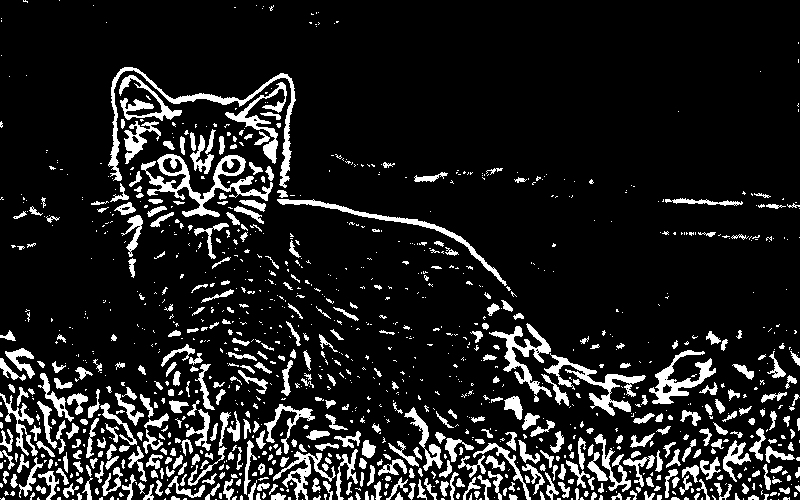

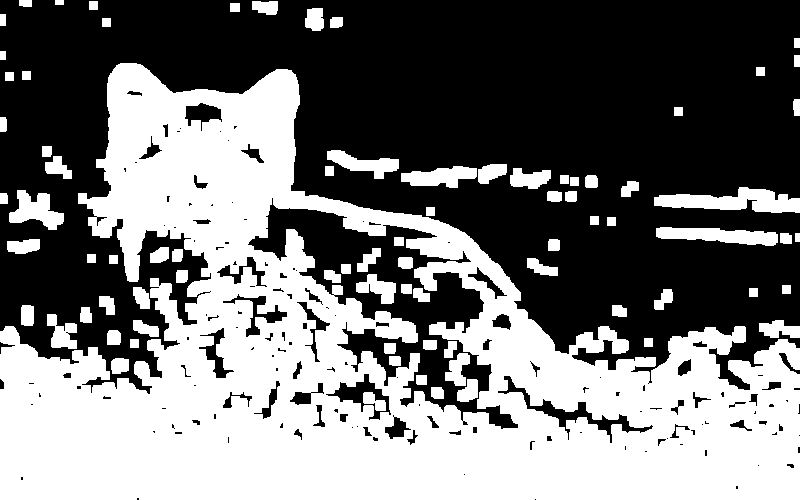

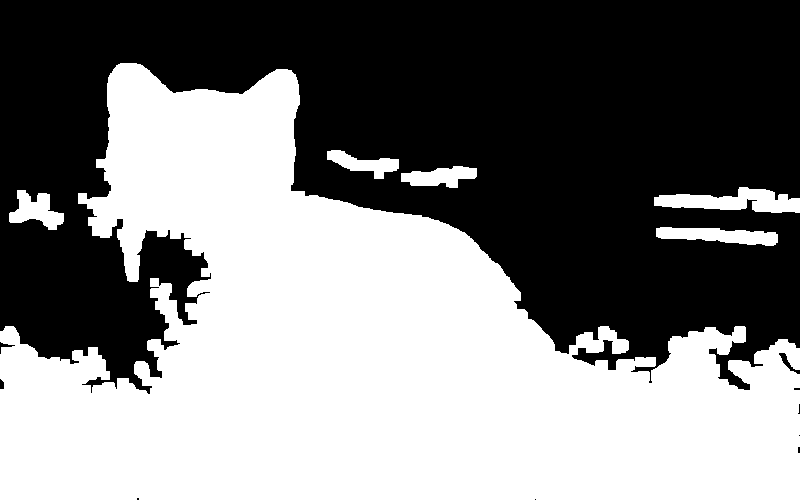

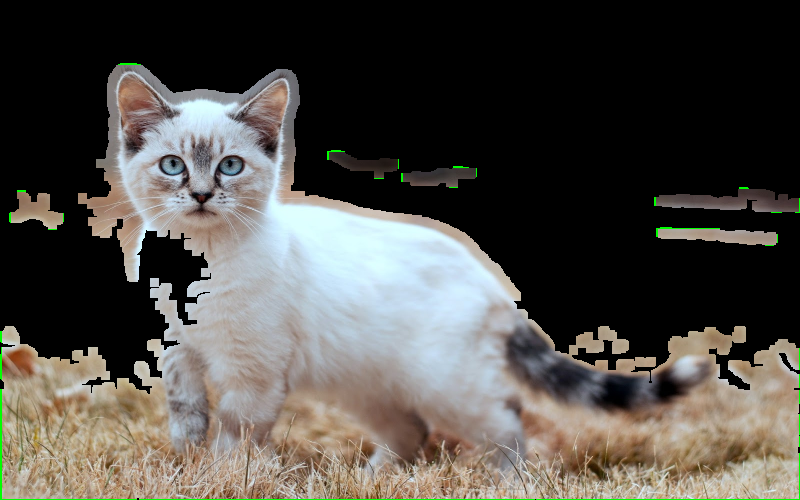

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =====================
# 1. LOAD GAMBAR
# =====================
image_path = 'Kucing2.JPG'
image = cv2.imread(image_path)
image = cv2.resize(image, (800, 500))

# =====================
# 2. PREPROCESSING
# =====================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)

# =====================
# 3. ADAPTIVE THRESHOLD (LEBIH KUAT)
# =====================
thresh = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

# =====================
# 4. MORPHOLOGY (BERSIHKAN & SATUKAN OBJEK)
# =====================
kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
mask = cv2.dilate(mask, kernel, iterations=2)

# =====================
# 5. CONTOUR
# =====================
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

final_mask = np.zeros_like(gray)

object_count = 0

# =====================
# 6. HITUNG OBJEK
# =====================
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 800:  # lebih kecil biar objek tetap terdeteksi
        object_count += 1

        cv2.drawContours(final_mask, [cnt], -1, 255, -1)

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(image, (x,y), (x+w, y+h), (0,255,0), 2)

# =====================
# 7. HASIL
# =====================
result = cv2.bitwise_and(image, image, mask=final_mask)

# =====================
# 8. TAMPILKAN
# =====================
print("Jumlah Objek:", object_count)

cv2_imshow(thresh)
cv2_imshow(mask)
cv2_imshow(final_mask)
cv2_imshow(result)